In [1]:
using DelimitedFiles
using Plots
using NonlinearEigenproblems
using LinearAlgebra
using PyCall
include("BaseFlow_cavity.jl")
include("Stability_Cavity.jl")

mode = 1:cavity; mode = 2:stationary; mode = 3:rotation;


eig_full (generic function with 1 method)

In [2]:
## aixal flow stability
py""" 
import numpy as np
from scipy.integrate import solve_bvp

kappa = 1 # 注意：在外部需确保 Ro 被正确解析传入
Ts = 0.1

def oneDiskODE(z, y):
    # Y0 = H, Y1 = F', Y2 = F, Y3 = G', Y4 = G
    dydz = np.zeros((5, len(z)))
    dydz[0] = -2.0 * y[2]
    dydz[1] = kappa * (y[2]**2 + y[0]*y[1] - (y[4]**2 - 1.0)) - (2.0 - kappa - kappa**2)*(y[4] - 1.0) + Ts**2
    dydz[2] = y[1]
    dydz[3] = kappa * (2.0*y[2]*y[4] + y[0]*y[3]) + (2.0 - kappa - kappa**2)*y[2]
    dydz[4] = y[3]
    return dydz 

def oneDiskBC(ya, yb):
    # 壁面 (z=0): H=0, F=0, G=0
    resa = np.array([ya[0], ya[2], ya[4]])
    # 远场 (z=30): F = -Ts, G = 1.0
    resb = np.array([yb[2] + Ts, yb[4] - 1.0])
    return np.concatenate((resa, resb))

# 【优化 1】减少初始网格点数，让求解器自己去自适应加密
z_init = np.linspace(0, 30, 500) 
y_guess = np.zeros((5, z_init.size))

# 【优化 2】构造满足边界条件的平滑初始场 (指数过渡)
# z=0时全为0; z无穷大时满足远场条件
y_guess[0, :] = 0.0                             # H: 初始简单设为0
y_guess[2, :] = -Ts * (1.0 - np.exp(-z_init))   # F: 从 0 过渡到 -Ts
y_guess[4, :] = 1.0 - np.exp(-z_init)           # G: 从 0 过渡到 1.0

# 导数项 F' 和 G' 也可以由上面的解析求导得到（有助于进一步加速收敛）
y_guess[1, :] = -Ts * np.exp(-z_init)           # F'
y_guess[3, :] = np.exp(-z_init)                 # G'

# 【优化 3】求解。如果 1e-10 难收敛，可以先用 1e-6 算一个粗解，再作为新猜测值代入
solution = solve_bvp(oneDiskODE, oneDiskBC, z_init, y_guess, tol=1e-10, max_nodes=100000)

# 求解完成后，在你需要的高密度网格上进行插值输出
x_plot = np.linspace(0, 30, 2000)

if solution.success:
    # solution.sol 自动处理了样条插值
    y1_plot = solution.sol(x_plot)[0]  # H
    y2_plot = solution.sol(x_plot)[2]  # F
    y3_plot = solution.sol(x_plot)[4]  # G
    y4_plot = solution.sol(x_plot)[1]  # F'
    y5_plot = solution.sol(x_plot)[3]  # G'
else:
    print("求解失败:", solution.message)
    """
    w0 = py"y1_plot"
    u0 = py"y2_plot"
    v0 = py"y3_plot"
    du0 = py"y4_plot"
    dv0 = py"y5_plot"
    z = py"x_plot";

In [2]:
py"""
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import math
from math import sqrt
Re_s = 1000
a = -0.2
def oneDiskODE(z,y):
        # # Y0 = H, Y1 = F,Y2 = F', Y3 = F'', Y4 = G, Y5 = G'
        dH = -2 * sqrt(Re_s) * y[1]
        dydz = np.zeros((6, len(z)))
        dydz = np.array([dH , y[2] , y[3] , Re_s * ( (1/sqrt(Re_s)) * ( y[3] * y[0] + y[2] * dH) - 2 * y[4] * y[5] + 2 * y[1] * y[2]) , y[5] , Re_s * ( (1/sqrt(Re_s)) * y[5] * y[0] + 2 * y[1] * y[4])])
        return dydz 

def oneDiskBC(ya, yb):
        resa = np.array([ya[0] + a,ya[1], ya[4] - 1])
        
        resb = np.array([yb[0],yb[1], yb[4] - 0])
        
        return np.concatenate((resa, resb))


z = np.linspace(0, 1, 100)
y = np.zeros((6, len(z)))
y_guess = np.zeros((6, z.size))
y_guess[0] = 0
y_guess[1] = 0
y_guess[2] = 0
y_guess[3] = 0
y_guess[4] = 1
y_guess[5] = 0
solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,max_nodes=5000000)

x_plot = np.linspace(0, 1, 2000)


y1_plot = solution.sol(x_plot)[0]
y2_plot = solution.sol(x_plot)[1]
y3_plot = solution.sol(x_plot)[4]
y4_plot = solution.sol(x_plot)[2]
y5_plot = solution.sol(x_plot)[5]
"""
w0 = py"y1_plot"
u0 = py"y2_plot"
v0 = py"y3_plot"
du0 = py"y4_plot"
dv0 = py"y5_plot"
z = py"x_plot";

In [3]:
N_cheb = 129
mode = 1
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode);

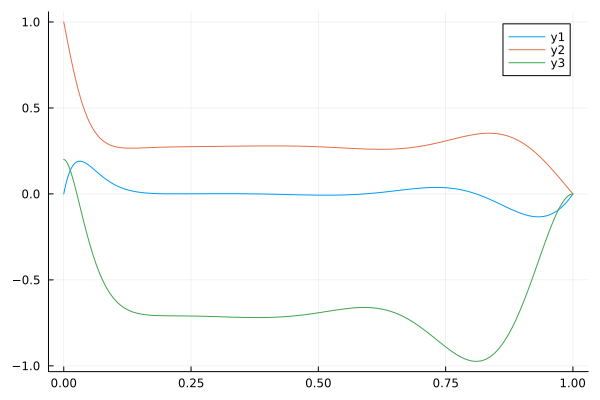

In [4]:
plot(z,F)
plot!(z,G)
plot!(z,H)

In [5]:
R = 278.6
be = 0.08
OMEGA = 2.19
omega = OMEGA/R
c = 0.3
Res = 1000
cof = Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega,R)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 3,maxit = 500 , tol=1e-14)
vel = eig_full(eigvec,N_cheb,1)
@show eigval

eigval = ComplexF64[0.385627277633784 - 0.026458542109483715im, 0.23664542276994677 + 0.04872908684316078im, 0.3223356317437194 + 0.2315713534250234im]


3-element Vector{ComplexF64}:
   0.385627277633784 - 0.026458542109483715im
 0.23664542276994677 + 0.04872908684316078im
  0.3223356317437194 + 0.2315713534250234im